<a href="https://colab.research.google.com/github/nathaliaacouto/ADES_Wine_Quality/blob/main/%5BADES%5D_Wine_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Data Analysis and Machine Learning

This notebook presents a complete data analysis pipeline for the **WineQT** dataset.  
The main objective is to analyse the physicochemical properties of wine and predict its quality using machine learning techniques.

## Goals
- Understand the structure and quality of the dataset
- Perform preprocessing and exploratory data analysis
- Identify relevant patterns and correlations
- Apply supervised and unsupervised machine learning algorithms
- Interpret the main findings

Dataset Link: https://archive.ics.uci.edu/dataset/186/wine+quality

## 1. Install and import required libraries

In [176]:
import importlib
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn"
}

for import_name, package_name in required_packages.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

In [177]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load the dataset
Make sure the file `WineQT.csv` is in the same folder as this notebook.

In [178]:
df = pd.read_csv('WineQT.csv')

In [179]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 3. Initial dataset inspection
We start by checking the shape, column names, data types, and a quick statistical summary.

In [180]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (6497, 13)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']


In [181]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [182]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.9000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.5800
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.6600
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.8000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.6110
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.0000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.0000
density,6497.0,0.997650,0.025023,0.98711,0.99234,0.99489,0.99699,1.2026
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.0100
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.0000


## 4. Problem statement

The objective of this project is to analyse the physicochemical properties of wine and understand how they influence its quality.

Additionally, we aim to develop machine learning models capable of predicting wine quality based on these features.

## 5. Data quality checks

### 5.1 Missing values
We first check whether the dataset contains null values.

In [183]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


**Interpretation:**  
The dataset does not contain missing values, so no imputation is required.

### 5.2 Duplicate rows
It is also useful to verify if duplicate observations exist.

In [184]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100
rows_after_dropping_duplicates = df.drop_duplicates().shape[0]

print("Number of fully duplicated rows:", duplicate_count)
print(f"Percentage of duplicated rows: {duplicate_percentage:.2f}%")
print("Number of rows if exact duplicates were removed:", rows_after_dropping_duplicates)

Number of fully duplicated rows: 1177
Percentage of duplicated rows: 18.12%
Number of rows if exact duplicates were removed: 5320


**Interpretation:**  
The dataset contains exact duplicate rows, representing a noticeable part of the observations. However, the dataset does not include a unique sample identifier, so identical physicochemical measurements cannot automatically be treated as data-entry errors. Removing them could also remove legitimate repeated observations and change the empirical distribution of the data. Therefore, the duplicates are retained and treated as a limitation to consider during interpretation.

## 6. Exploratory Data Analysis

### 6.1 Target variable distribution
Understanding the distribution of the target variable is important before training models.

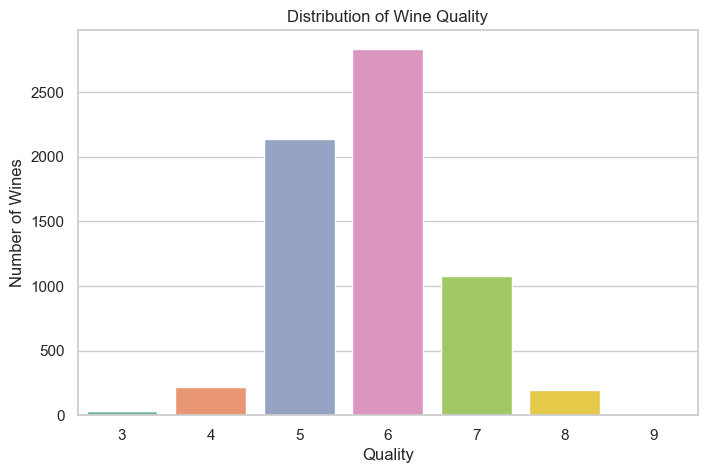

In [185]:
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df, hue="quality", palette="Set2", legend=False)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Number of Wines")
plt.show()

In [186]:
quality_distribution = df["quality"].value_counts().sort_index()
quality_distribution

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [187]:
quality_distribution_normalized = df["quality"].value_counts(normalize=True).sort_index() * 100
quality_distribution_normalized.round(2)

quality
3     0.46
4     3.32
5    32.91
6    43.65
7    16.61
8     2.97
9     0.08
Name: proportion, dtype: float64

**Interpretation:**  
The target variable is not perfectly balanced. Most wines are concentrated around quality levels **5** and **6**, while extreme quality values are less frequent. This imbalance should be considered during modelling and interpretation.

### 6.2 Correlation heatmap
A correlation matrix helps identify linear relationships between features and with the target variable.

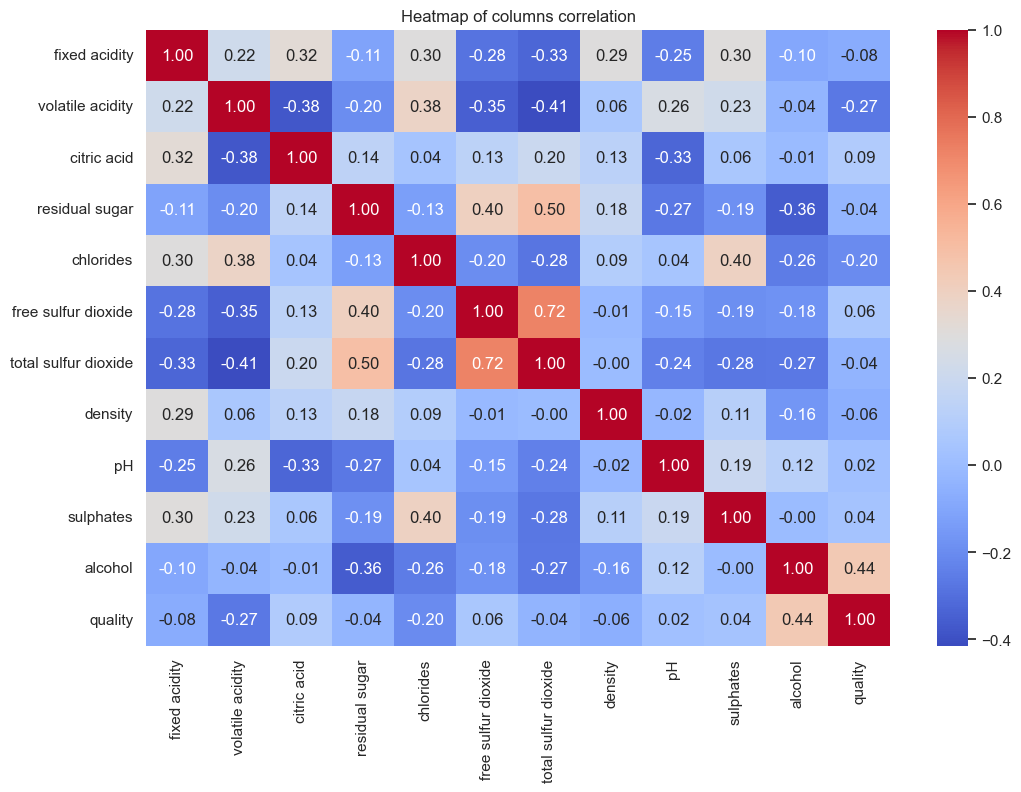

In [188]:
correlation = df.corr(numeric_only=True) # Only numeric columns are included; type is categorical.

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of columns correlation')
plt.show()

**Interpretation:**  
This heatmap helps identify features that may be positively or negatively associated with wine quality. In the computed matrix, **alcohol** shows a positive association with quality, while **volatile acidity** shows a negative association.

### 6.3 Scatter plots between important variables and quality
Scatter plots help visualise direct relationships between relevant features and the target variable.

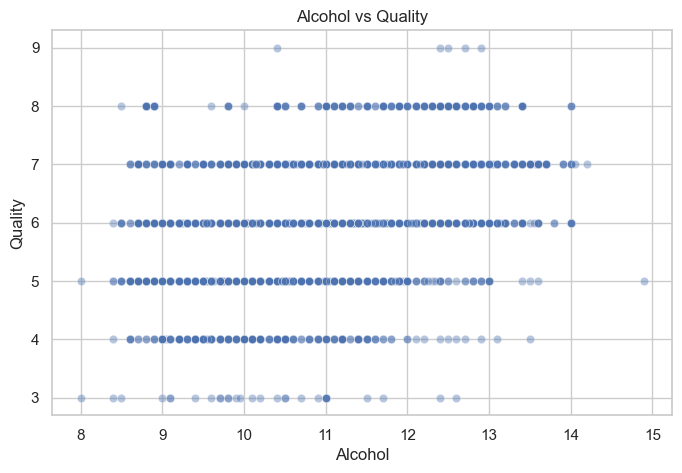

In [189]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='alcohol', y='quality', data=df, alpha=0.4)
plt.title('Alcohol vs Quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

**Interpretation:**  
This plot suggests that wines with higher alcohol content tend to have higher quality scores, although the relationship is not perfectly linear.

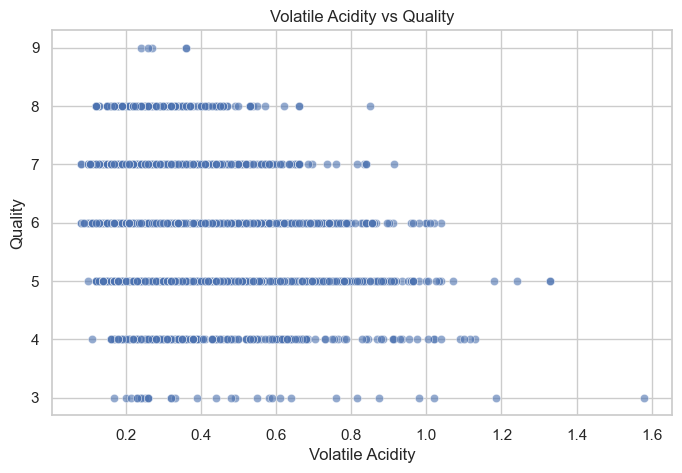

In [190]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='volatile acidity', y='quality', data=df, alpha=0.6)
plt.title('Volatile Acidity vs Quality')
plt.xlabel('Volatile Acidity')
plt.ylabel('Quality')
plt.show()

**Interpretation:**  
Higher volatile acidity is generally associated with lower quality scores, which is consistent with the correlations observed earlier.

### 6.4 Boxplots by quality
Boxplots are useful for visualising distributions and potential outliers for each feature across quality levels.

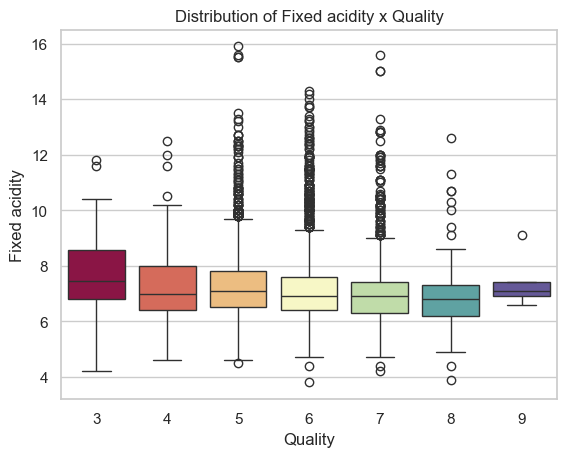

In [191]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='fixed acidity', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Fixed acidity x Quality')
plt.ylabel('Fixed acidity')
plt.xlabel('Quality')
plt.show()

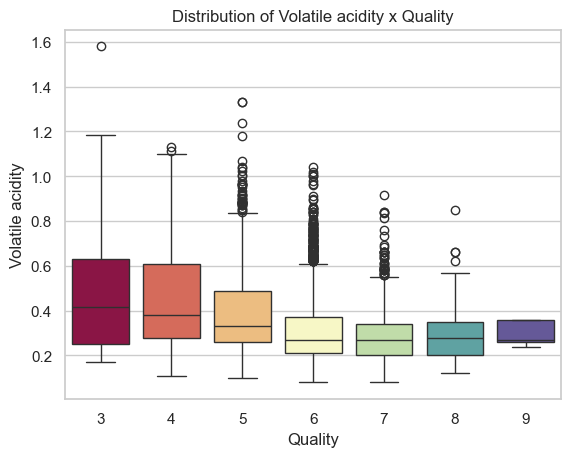

In [192]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='volatile acidity', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Volatile acidity x Quality')
plt.ylabel('Volatile acidity')
plt.xlabel('Quality')
plt.show()

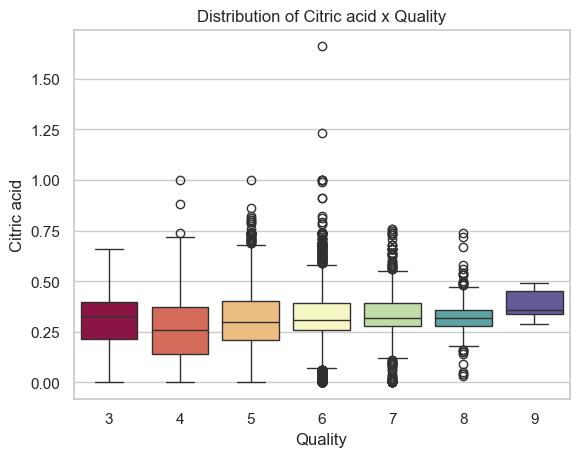

In [193]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='citric acid', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Citric acid x Quality')
plt.ylabel('Citric acid')
plt.xlabel('Quality')
plt.show()

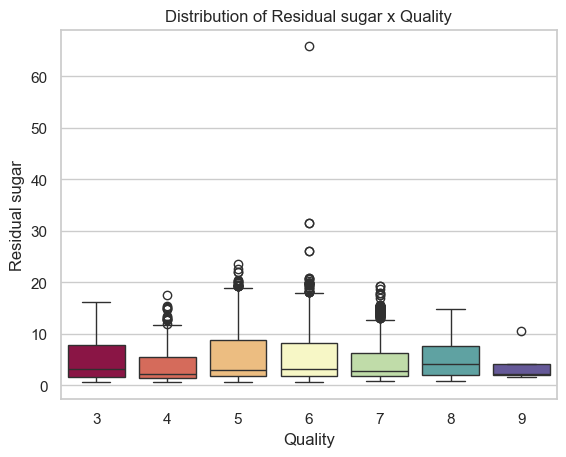

In [194]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='residual sugar', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Residual sugar x Quality')
plt.ylabel('Residual sugar')
plt.xlabel('Quality')
plt.show()

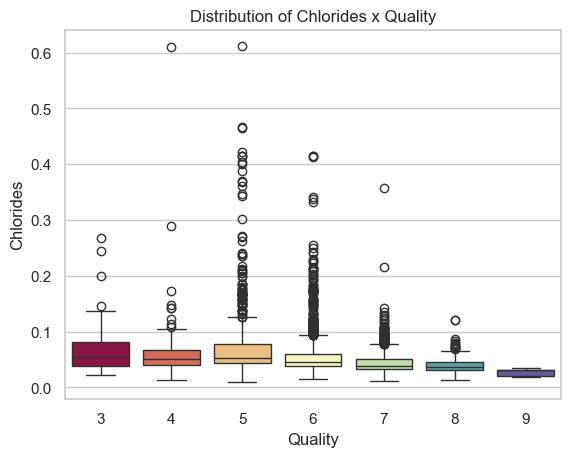

In [195]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='chlorides', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Chlorides x Quality')
plt.ylabel('Chlorides')
plt.xlabel('Quality')
plt.show()

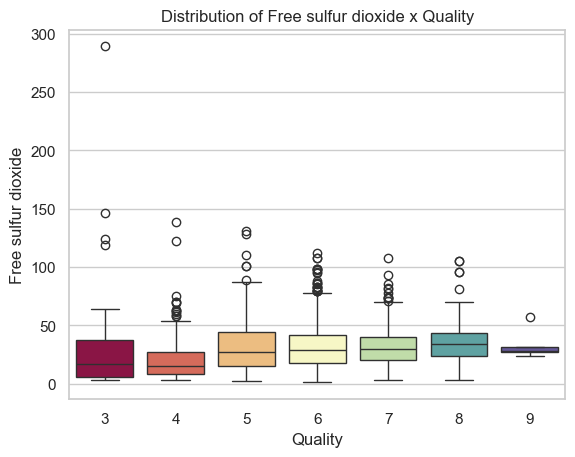

In [196]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='free sulfur dioxide', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Free sulfur dioxide x Quality')
plt.ylabel('Free sulfur dioxide')
plt.xlabel('Quality')
plt.show()

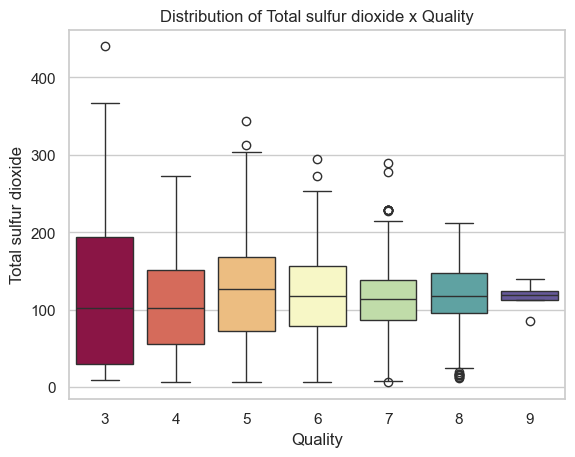

In [197]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='total sulfur dioxide', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Total sulfur dioxide x Quality')
plt.ylabel('Total sulfur dioxide')
plt.xlabel('Quality')
plt.show()

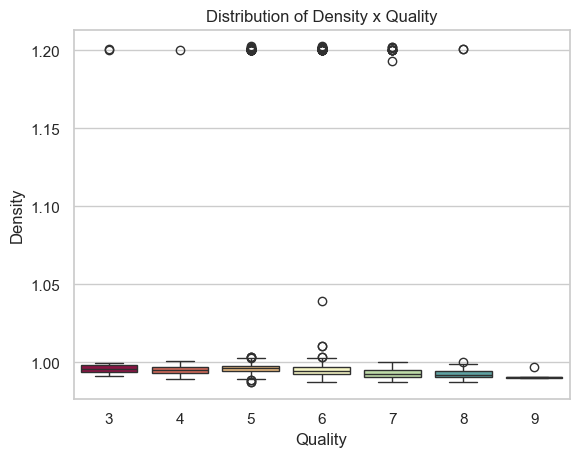

In [198]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='density', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Density x Quality')
plt.ylabel('Density')
plt.xlabel('Quality')
plt.show()

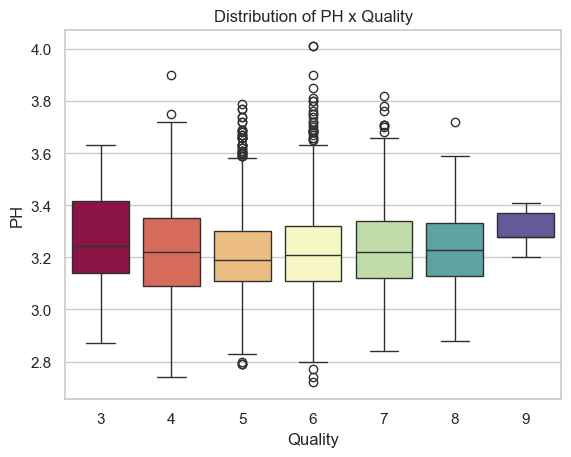

In [199]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='pH', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of PH x Quality')
plt.ylabel('PH')
plt.xlabel('Quality')
plt.show()

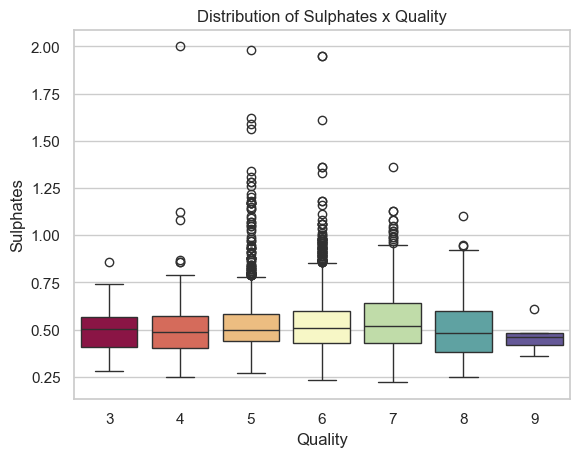

In [200]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='sulphates', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Sulphates x Quality')
plt.ylabel('Sulphates')
plt.xlabel('Quality')
plt.show()

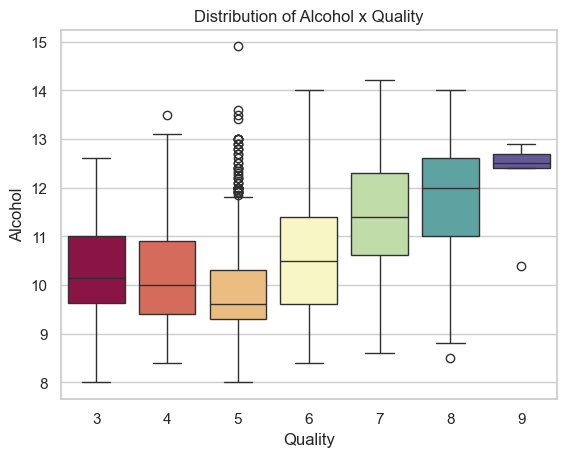

In [201]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='alcohol', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Alcohol x Quality')
plt.ylabel('Alcohol')
plt.xlabel('Quality')
plt.show()

### 6.5 Histograms of the main variables
Histograms help us inspect the distribution of each numeric feature.

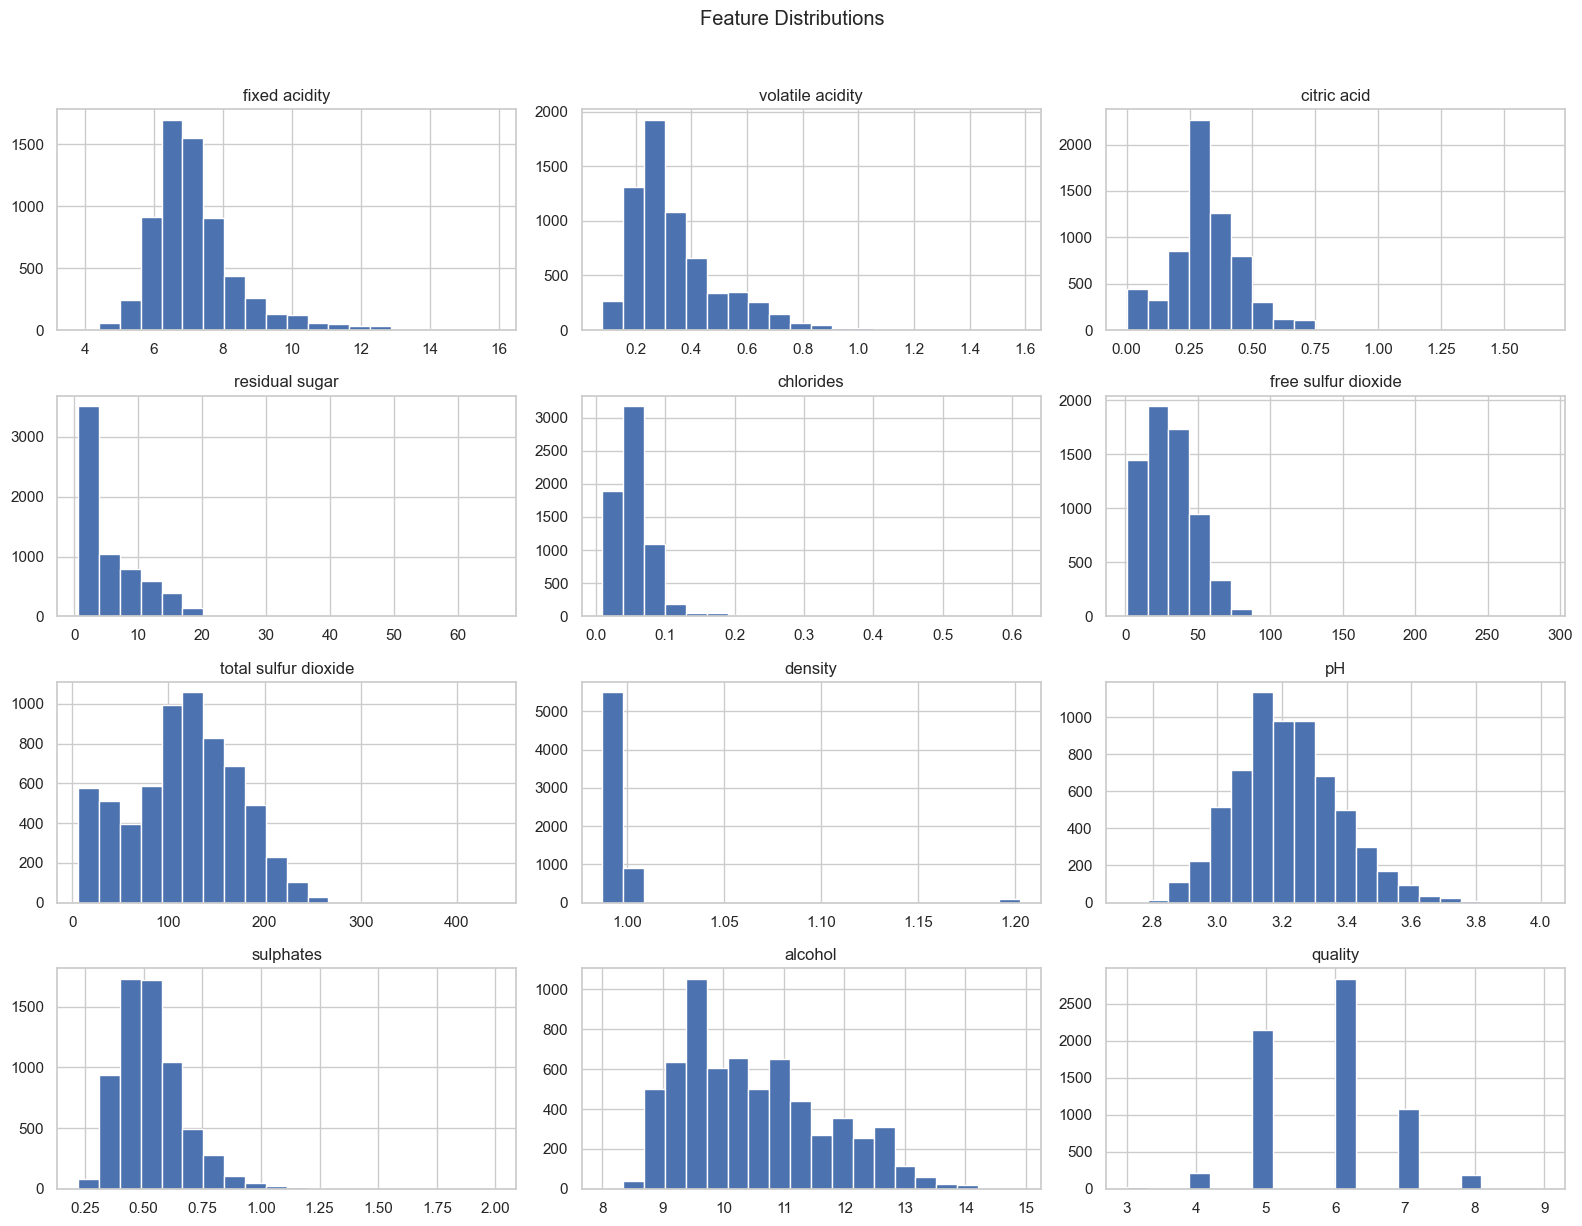

In [202]:
df.hist(figsize=(16, 12), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

## 7. Preprocessing

Before applying machine learning models, the dataset must be prepared to ensure that the input variables are suitable for analysis.

The preprocessing phase includes:
- removing non-informative attributes
- creating a simplified target for binary classification
- separating features and target variables
- scaling the input features

These steps help improve the quality of the analysis and the performance of the models.

### 7.1 Create a binary target variable

The original `quality` variable contains several classes.  
To simplify the classification task, a binary version of the target is created:

- `1` → good quality wine (`quality >= 6`)
- `0` → bad quality wine (`quality < 6`)

This transformation makes the prediction task easier to interpret and can also help reduce class sparsity.

In [203]:
df['quality_binary'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

df[['quality', 'quality_binary']].head()

,quality,quality_binary
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0


### 7.2 Check the distribution of the binary target

After creating the binary target, it is important to inspect its distribution to understand whether the classes are balanced.

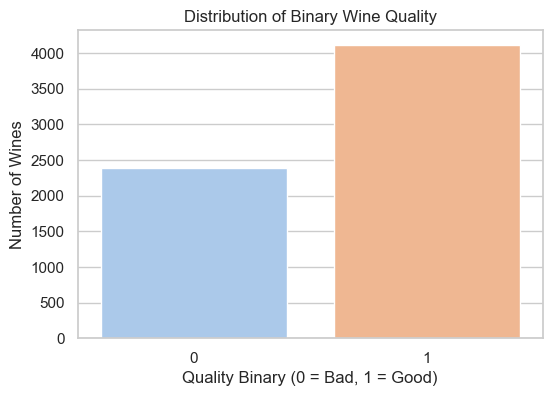

In [204]:
plt.figure(figsize=(6, 4))
sns.countplot(x='quality_binary', data=df, hue='quality_binary', palette='pastel', legend=False)
plt.title('Distribution of Binary Wine Quality')
plt.xlabel('Quality Binary (0 = Bad, 1 = Good)')
plt.ylabel('Number of Wines')
plt.show()

In [205]:
df['quality_binary'].value_counts()

quality_binary
1    4113
0    2384
Name: count, dtype: int64

### 7.3 Separate input features and target variables

The dataset is now divided into:

- `X` → input features
- `y_multi` → original multiclass target (`quality`)
- `y_binary` → binary target (`quality_binary`)

This separation is necessary before applying machine learning algorithms.

In [206]:
X = df.drop(['quality', 'quality_binary'], axis=1)
y_multi = df['quality']
y_binary = df['quality_binary']

print("X shape:", X.shape)
print("y_multi shape:", y_multi.shape)
print("y_binary shape:", y_binary.shape)

X shape: (6497, 12)
y_multi shape: (6497,)
y_binary shape: (6497,)


### 7.4 Feature encoding and scaling

The dataset contains one categorical variable, `type`, which must be converted into numeric form before modelling.

The numeric variables are also measured on different scales. For example, `total sulfur dioxide` has much larger numerical values than `pH` or `chlorides`.

To prevent variables with larger magnitudes from dominating scale-sensitive algorithms, the input features are standardized using `StandardScaler`. To avoid data leakage, the scaler is fitted only on the training data after the train-test split, and then applied to the test data.

Feature scaling is especially important for algorithms such as Logistic Regression and K-Means.

In [207]:
X = df.drop(['quality', 'quality_binary'], axis=1)
X = pd.get_dummies(X, columns=['type'], drop_first=True)

X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,False


In [208]:
print("Encoded feature columns:")
print(X.columns.tolist())

Encoded feature columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type_white']


### 7.5 Preprocessing summary

At the end of preprocessing, the dataset is ready for machine learning tasks.

The following steps were completed:
- creation of a binary target variable
- separation of features and targets
- encoding of the categorical `type` variable
- standardization of input variables fitted on the training data only

These transformations ensure that the data is in a suitable format for both supervised and unsupervised learning methods while avoiding leakage in supervised model evaluation.

### Exploratory Data Analysis Summary

Before applying machine learning models, the exploratory data analysis revealed several relevant patterns in the dataset.

**Alcohol shows a positive relationship with wine quality**

Higher alcohol values tend to be associated with better quality scores. This suggests that alcohol may be an important predictor in the modelling stage.

**Volatile acidity shows a negative relationship with wine quality**

Wines with higher volatile acidity generally tend to have lower quality ratings. This indicates that this feature may have a significant influence on wine quality.

**The original target variable is imbalanced**

Most observations are concentrated around the middle quality levels, while very low and very high quality scores are less frequent. This imbalance should be considered when evaluating model performance.

**Several features contain outliers**

Some variables, such as residual sugar, chlorides, and sulphates, show extreme values. These outliers may affect both statistical interpretation and the behaviour of machine learning models.

**The dataset is clean and well-structured**

No missing values were identified in the dataset. This improves data quality and reduces the amount of preprocessing required before modelling.

**Summary**

Overall, the exploratory analysis helped identify the most relevant variables, detect potential issues such as imbalance and outliers, and confirm that the dataset is suitable for the next stages of preprocessing and machine learning.

## 8. Supervised Learning

To evaluate the predictive performance of the selected machine learning algorithms, the dataset was divided into training and testing subsets.

A stratified split was used to preserve the class distribution of the binary target variable in both subsets. Feature scaling was fitted only on the training set and then applied to the test set to prevent data leakage.

### 8.1 Train-Test Split

In [209]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train = pd.DataFrame(X_train, columns=X.columns, index=X_train_raw.index)
X_test = pd.DataFrame(X_test, columns=X.columns, index=X_test_raw.index)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5197, 12)
X_test shape: (1300, 12)
y_train shape: (5197,)
y_test shape: (1300,)


### 8.2 Logistic Regression

Logistic Regression was selected as a baseline model for binary classification.

It is a simple and interpretable algorithm, making it a useful starting point for comparing performance with more complex models.

In [210]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.7476923076923077
Precision: 0.7734806629834254
Recall: 0.850546780072904
F1-score: 0.8101851851851852
Balanced Accuracy: 0.7103886940196804
ROC-AUC: 0.8051995689951628

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.57      0.62       477
           1       0.77      0.85      0.81       823

    accuracy                           0.75      1300
   macro avg       0.73      0.71      0.72      1300
weighted avg       0.74      0.75      0.74      1300

Confusion Matrix:
 [[272 205]
 [123 700]]


### 8.3 Decision Tree

The Decision Tree classifier was applied to analyse whether a non-linear model could better capture the relationships between the features and wine quality.

This model is also useful because of its interpretability.

In [211]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.7776923076923077
Precision: 0.8272058823529411
Recall: 0.8201701093560145
F1-score: 0.823672971323978
Balanced Accuracy: 0.7622863125396424
ROC-AUC: 0.7622863125396426

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.70      0.70       477
           1       0.83      0.82      0.82       823

    accuracy                           0.78      1300
   macro avg       0.76      0.76      0.76      1300
weighted avg       0.78      0.78      0.78      1300

Confusion Matrix:
 [[336 141]
 [148 675]]


### 8.4 Random Forest

Random Forest was selected as an ensemble model that combines multiple decision trees.

This approach usually improves predictive performance and reduces the instability associated with individual trees.

In [212]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8415384615384616
Precision: 0.8541905855338691
Recall: 0.9040097205346294
F1-score: 0.8783943329397875
Balanced Accuracy: 0.8188811705398513
ROC-AUC: 0.9040300990139364

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.73      0.77       477
           1       0.85      0.90      0.88       823

    accuracy                           0.84      1300
   macro avg       0.84      0.82      0.83      1300
weighted avg       0.84      0.84      0.84      1300

Confusion Matrix:
 [[350 127]
 [ 79 744]]


### 8.5 Model Comparison

After training the selected supervised learning models, their performance was compared using standard classification metrics.

This comparison helps identify the most suitable model for the wine quality classification task.

In [213]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_dt),
        balanced_accuracy_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

results = results.sort_values(by="F1-score", ascending=False)
results

,Model,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,ROC-AUC
2,Random Forest,0.841538,0.854191,0.904010,0.878394,0.818881,0.904030
1,Decision Tree,0.777692,0.827206,0.820170,0.823673,0.762286,0.762286
0,Logistic Regression,0.747692,0.773481,0.850547,0.810185,0.710389,0.805200


### 8.6 Visual Comparison of Model Performance

To support interpretation, the performance of the supervised learning models was also visualised using a bar chart.

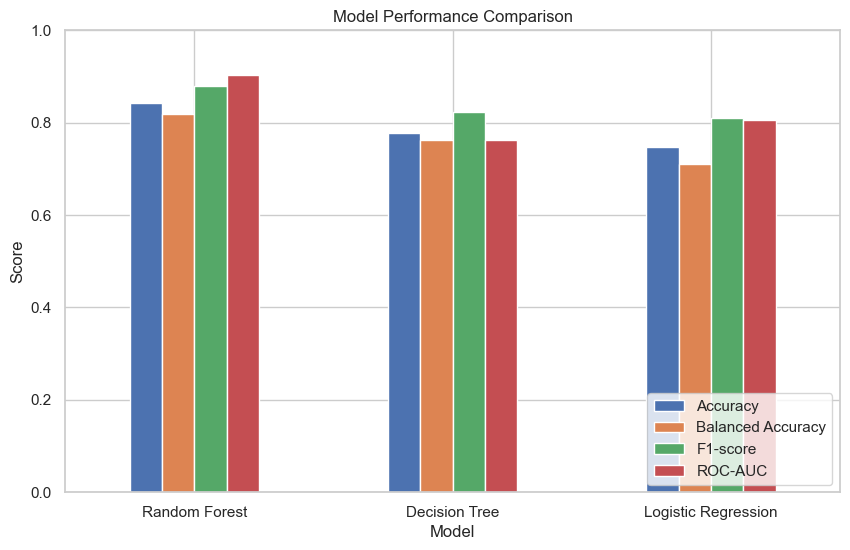

In [214]:
results.set_index("Model")[["Accuracy", "Balanced Accuracy", "F1-score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

#### Interpretation of the Model Performance Comparison

The bar chart illustrates the performance of the supervised learning models across Accuracy, Balanced Accuracy, F1-score, and ROC-AUC.

Among the evaluated models, Random Forest achieved the strongest overall performance. This is especially important because the binary target is moderately imbalanced, so Balanced Accuracy, F1-score, and ROC-AUC provide a more reliable interpretation than Accuracy alone.

The Decision Tree also performed better than Logistic Regression on most metrics, suggesting that non-linear relationships are useful for this task. Logistic Regression remains a useful baseline because it is simple and interpretable, but it is less effective than the tree-based models on this dataset.

Overall, the results suggest that Random Forest is the most suitable supervised model among the three tested models, while still leaving room for error and uncertainty in individual predictions.

### 8.7 Interpretation of Supervised Learning Results

The supervised learning models achieved different levels of performance in predicting binary wine quality, showing that some algorithms are better suited than others for this classification task.

Logistic Regression provided a useful baseline model. Although its performance was acceptable, it was less effective in capturing more complex relationships between the physicochemical properties and wine quality. In contrast, the tree-based models, especially Random Forest, achieved stronger results across the main evaluation metrics.

The Decision Tree model improved the classification results when compared to Logistic Regression, suggesting that the relationship between the input variables and wine quality is not purely linear. However, Random Forest outperformed the other tested models, achieving the highest F1-score, Balanced Accuracy, and ROC-AUC.

These findings indicate that machine learning techniques can support wine quality prediction based on physicochemical properties, but the predictions are not perfect. The results should therefore be interpreted as useful predictive evidence rather than a complete explanation of wine quality.

#### Best Performing Model

Based on the evaluation metrics, the Random Forest classifier achieved the best overall performance among the tested models. For this reason, it was selected as the most suitable supervised model for predicting binary wine quality in this study.

### 8.8 Cross-Validation

To ensure the robustness and reliability of the supervised learning models, cross-validation was applied. This technique evaluates model performance across multiple data splits, reducing the risk of overfitting and providing a more reliable estimate of generalisation performance.

In this study, 5-fold cross-validation was used to assess the accuracy of the Logistic Regression, Decision Tree, and Random Forest models.

In [215]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "Accuracy": "accuracy",
    "Balanced Accuracy": "balanced_accuracy",
    "F1-score": "f1",
    "ROC-AUC": "roc_auc"
}

cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    scores = cross_validate(
        pipeline,
        X,
        y_binary,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores["test_Accuracy"].mean(),
        "SD Accuracy": scores["test_Accuracy"].std(),
        "Mean Balanced Accuracy": scores["test_Balanced Accuracy"].mean(),
        "SD Balanced Accuracy": scores["test_Balanced Accuracy"].std(),
        "Mean F1-score": scores["test_F1-score"].mean(),
        "SD F1-score": scores["test_F1-score"].std(),
        "Mean ROC-AUC": scores["test_ROC-AUC"].mean(),
        "SD ROC-AUC": scores["test_ROC-AUC"].std()
    })

cv_summary = pd.DataFrame(cv_results).set_index("Model")
cv_summary

,Mean Accuracy,SD Accuracy,Mean Balanced Accuracy,SD Balanced Accuracy,Mean F1-score,SD F1-score,Mean ROC-AUC,SD ROC-AUC
Model,,,,,,,,
Logistic Regression,0.745729,0.006053,0.709162,0.009689,0.808270,0.003717,0.802427,0.002296
Decision Tree,0.779898,0.011725,0.761180,0.009746,0.826989,0.010696,0.761180,0.009746
Random Forest,0.839772,0.005702,0.818880,0.007866,0.876396,0.004544,0.910065,0.005632


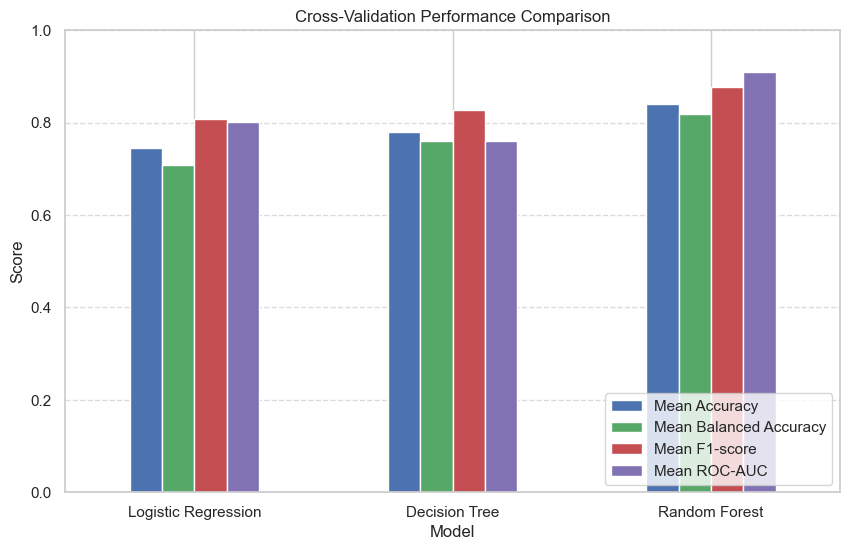

In [216]:
cv_summary[["Mean Accuracy", "Mean Balanced Accuracy", "Mean F1-score", "Mean ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 6),
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"]
)

plt.title("Cross-Validation Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right")
plt.show()

### 8.9 Handling class imbalance with class weights

In [217]:
balanced_models = {
    "Logistic Regression Balanced": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),
    "Decision Tree Balanced": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest Balanced": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )
}

balanced_cv_results = []

for name, model in balanced_models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y_binary,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    balanced_cv_results.append({
        "Model": name,
        "Mean Accuracy": scores["test_Accuracy"].mean(),
        "Mean Balanced Accuracy": scores["test_Balanced Accuracy"].mean(),
        "Mean F1-score": scores["test_F1-score"].mean(),
        "Mean ROC-AUC": scores["test_ROC-AUC"].mean()
    })

balanced_cv_summary = pd.DataFrame(balanced_cv_results).set_index("Model")
balanced_cv_summary

,Mean Accuracy,Mean Balanced Accuracy,Mean F1-score,Mean ROC-AUC
Model,,,,
Logistic Regression Balanced,0.727105,0.730508,0.768982,0.802532
Decision Tree Balanced,0.777899,0.760043,0.825009,0.760043
Random Forest Balanced,0.834539,0.812189,0.872699,0.909397


#### Interpretation of class imbalance handling

Class imbalance occurs when one class has significantly more instances than the other (for example: in this dataset, if 90% of the wines are classified as good quality and only 10% as bad quality). This can lead models to favour the majority class and overlook the minority class.

Since the binary target variable presents a moderate class imbalance, class-weighted versions of the models were evaluated. The `class_weight="balanced"` parameter adjusts the importance of each class inversely proportional to its frequency allowing the model to give more attention to the minority class during training.

This step is important because traditional metrics such as Accuracy can be misleading in imbalanced scenarios as they may be biased towards the majority class. Therefore, additional metrics such as Balanced Accuracy, F1-score and ROC-AUC were used to provide a more reliable evaluation of model performance.

However, the obtained results indicate that the use of class-weighted models does not lead to a significant improvement when compared to the original models. In particular, the similarity between Accuracy and Balanced Accuracy across all models suggests that the class distribution is not highly skewed.

This observation implies that the dataset does not suffer from severe imbalance and consequently, the models are not strongly biased towards the majority class. As a result, explicitly handling class imbalance has a limited impact on predictive performance in this case.

In conclusion, although incorporating class weights is considered a good practice in classification tasks, especially under imbalance, the empirical results demonstrate that for this dataset its effect is minimal and does not justify a clear performance gain.

### 8.10 Feature Importance Analysis

To better understand the contribution of each physicochemical property to the prediction of wine quality, a feature importance analysis was conducted using the Random Forest classifier.

This analysis helps identify the most influential variables and provides valuable insights into the factors that determine wine quality.

In [218]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances
feature_importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Convert to DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_importances.index,
    "Importance": feature_importances.values
})

importance_df

,Feature,Importance
0,alcohol,0.159274
1,volatile acidity,0.116736
2,density,0.104884
3,total sulfur dioxide,0.083488
4,chlorides,0.080579
5,free sulfur dioxide,0.078872
6,sulphates,0.078066
7,citric acid,0.077808
8,residual sugar,0.076427
9,pH,0.072298


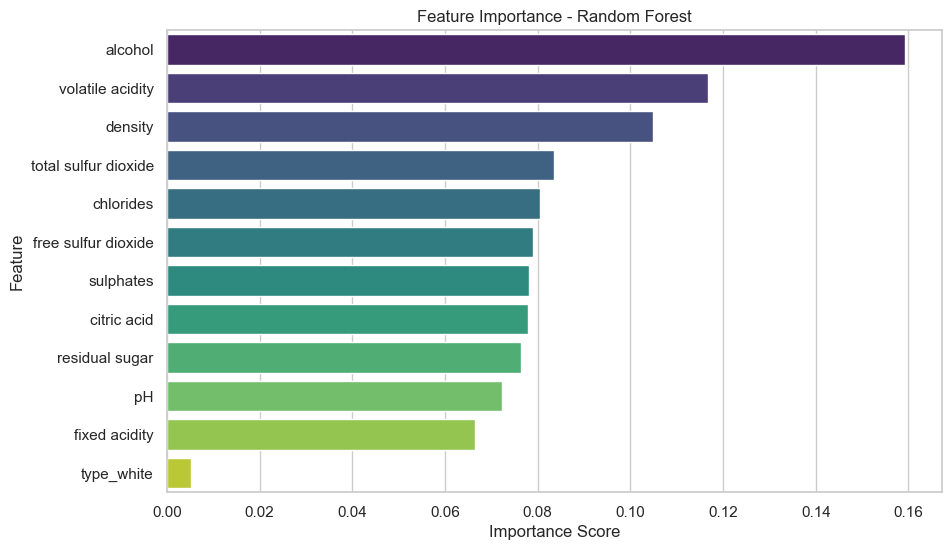

In [219]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df,
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

#### Interpretation of Feature Importance

The feature importance analysis indicates that **alcohol**, **volatile acidity**, and **density** are among the strongest predictors used by the Random Forest model.

This result is consistent with the exploratory analysis, where alcohol and volatile acidity showed clear associations with quality. However, Random Forest importance scores show how much each variable contributes to prediction; they do not indicate whether the effect is positive or negative. Therefore, the direction of the relationship should be interpreted together with the correlation and visual analysis rather than from feature importance alone.

## 9. Unsupervised Learning

K-Means clustering was applied to explore whether wines form natural groups based on their physicochemical properties.

For this unsupervised task, `quality`, `quality_binary`, and `type` were excluded from the clustering inputs. This avoids using the target variables and allows `type` to be used only later for interpretation.

In [220]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

cluster_features = df.drop(['quality', 'quality_binary', 'type'], axis=1)

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_features)

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cluster_scaled, cluster_labels))

cluster_selection = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

cluster_selection

,k,Inertia,Silhouette Score
0,2,57002.556682,0.278304
1,3,49257.753762,0.193272
2,4,44218.977834,0.212243
3,5,38624.577667,0.222896
4,6,36248.541917,0.177240
5,7,34035.511618,0.181530
6,8,32444.602327,0.172524
7,9,31272.021554,0.156009
8,10,30231.324780,0.142287


### 9.1 Elbow method and silhouette score

The elbow method helps inspect how within-cluster variation changes as the number of clusters increases. The silhouette score provides an additional measure of how well-separated the clusters are.

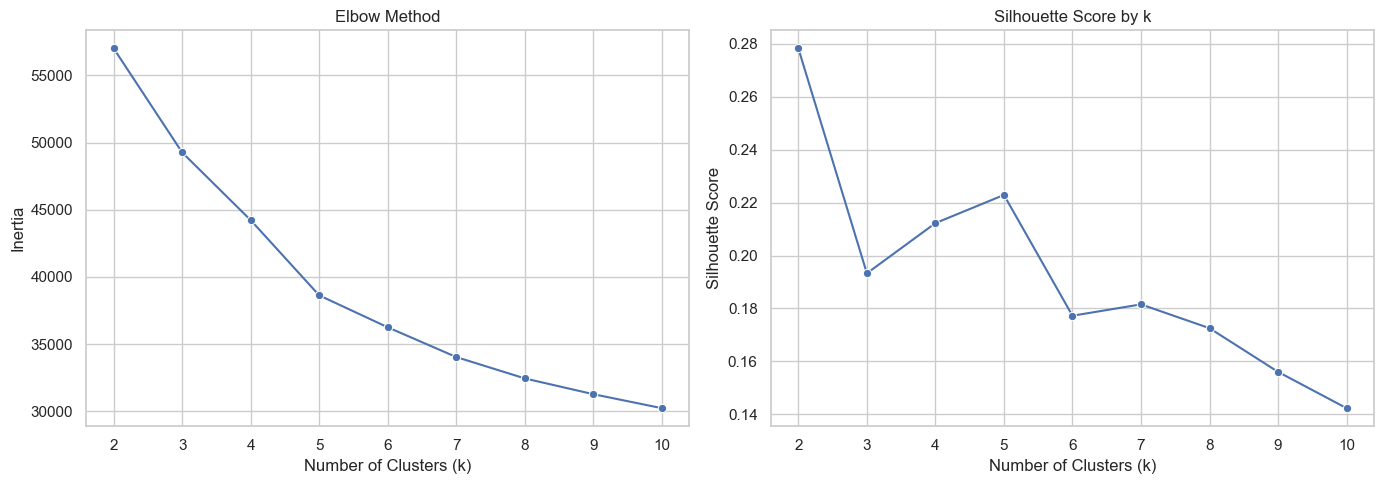

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x="k", y="Inertia", data=cluster_selection, marker="o", ax=axes[0])
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

sns.lineplot(x="k", y="Silhouette Score", data=cluster_selection, marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [222]:
best_k = cluster_selection.loc[cluster_selection["Silhouette Score"].idxmax(), "k"]

kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
df_clustered = df.copy()
df_clustered["cluster"] = kmeans.fit_predict(cluster_scaled)

print("Selected number of clusters:", int(best_k))
print("Best silhouette score:", cluster_selection["Silhouette Score"].max().round(3))

Selected number of clusters: 2
Best silhouette score: 0.278


### 9.2 Cluster interpretation

The following summaries compare the clusters with `quality`, `quality_binary`, and `type`. These variables were not used as clustering inputs, so they are used only to interpret the resulting groups.

In [223]:
cluster_quality_summary = df_clustered.groupby("cluster").agg(
    n=("quality", "size"),
    mean_quality=("quality", "mean"),
    good_quality_share=("quality_binary", "mean")
).round(3)

quality_binary_by_cluster = pd.crosstab(
    df_clustered["cluster"],
    df_clustered["quality_binary"],
    normalize="index"
).round(3)

type_by_cluster = pd.crosstab(
    df_clustered["cluster"],
    df_clustered["type"],
    normalize="index"
).round(3)

print("Cluster quality summary:")
display(cluster_quality_summary)

print("Quality binary distribution within each cluster:")
display(quality_binary_by_cluster)

print("Wine type distribution within each cluster:")
display(type_by_cluster)

Cluster quality summary:


,n,mean_quality,good_quality_share
cluster,,,
0,1683,5.596,0.521
1,4814,5.896,0.672


Quality binary distribution within each cluster:


quality_binary,0,1
cluster,,
0,0.479,0.521
1,0.328,0.672


Wine type distribution within each cluster:


type,red,white
cluster,,
0,0.935,0.065
1,0.005,0.995


In [224]:
cluster_feature_profile = pd.DataFrame(
    cluster_scaled,
    columns=cluster_features.columns
)
cluster_feature_profile["cluster"] = df_clustered["cluster"].values

cluster_feature_profile.groupby("cluster").mean().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
cluster,,,,,,,,,,,
0,0.80,1.15,-0.34,-0.61,0.89,-0.84,-1.19,0.19,0.55,0.83,-0.05
1,-0.28,-0.40,0.12,0.21,-0.31,0.29,0.41,-0.07,-0.19,-0.29,0.02


### 9.3 PCA visualisation

PCA with two components is used only as a visual aid. It reduces the standardized physicochemical variables to two dimensions, but it does not prove cluster separation on its own.

Explained variance by PC1 and PC2: [0.275 0.179]
Total explained variance: 0.454


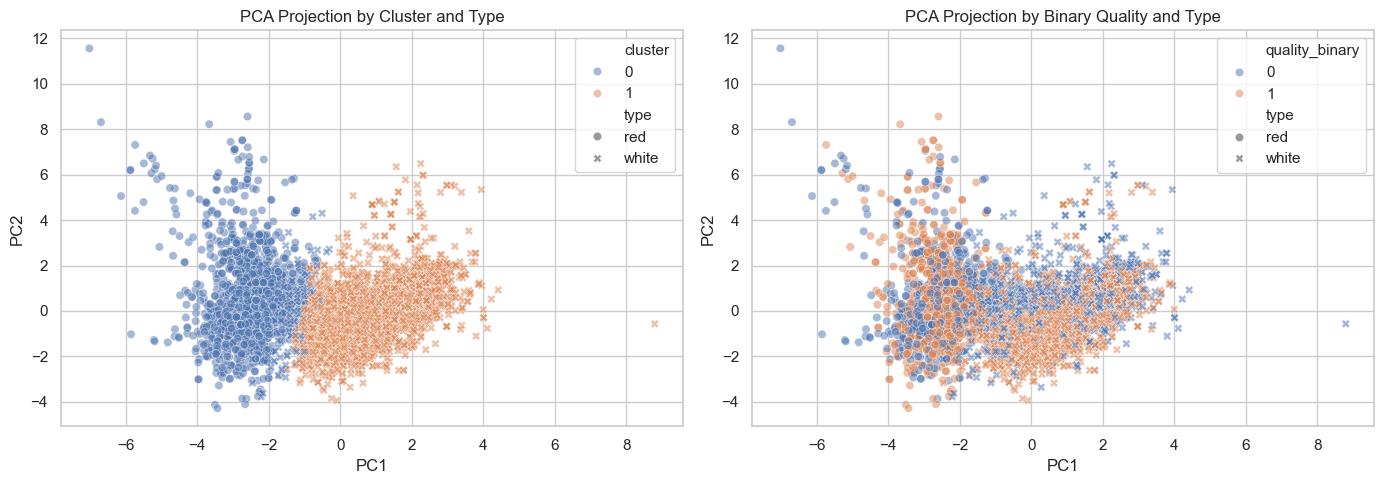

In [225]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(cluster_scaled)

pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df["cluster"] = df_clustered["cluster"].astype(str)
pca_df["quality_binary"] = df_clustered["quality_binary"].astype(str)
pca_df["type"] = df_clustered["type"]

print("Explained variance by PC1 and PC2:", pca.explained_variance_ratio_.round(3))
print("Total explained variance:", pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    style="type",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("PCA Projection by Cluster and Type")

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="quality_binary",
    style="type",
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("PCA Projection by Binary Quality and Type")

plt.tight_layout()
plt.show()

#### Interpretation of Unsupervised Learning

The silhouette score is highest for `k = 2`, but the score is modest, so the clusters should be interpreted as partially separated rather than clearly distinct groups.

The clusters separate wine `type` more strongly than wine quality. One cluster is mostly red wine, while the other is mostly white wine, even though `type` was not included as a clustering input. This suggests that the physicochemical variables contain strong information related to wine type.

The relationship with quality is weaker. The cluster dominated by white wines has a higher average quality and a higher share of wines labelled as good quality, but both clusters still contain a mix of low and high quality values. Therefore, K-Means provides useful descriptive structure, but it does not separate wine quality as clearly as it separates wine type-related chemistry.

The PCA plot supports this interpretation visually, but it should be treated only as a two-dimensional summary of the data rather than definitive proof of separation.

## 10. Overall Conclusion

This analysis shows that the WineQT dataset is suitable for exploratory analysis and machine learning, with no missing values but a notable number of exact duplicate rows. Because no unique sample identifier is available, duplicates were retained rather than assumed to be errors.

The exploratory analysis indicates that alcohol is positively associated with quality, while volatile acidity is negatively associated with quality. The target variable is concentrated around middle quality scores, so imbalance must be considered when evaluating models.

For supervised learning, Random Forest achieved the strongest overall performance among the tested models, especially when considering F1-score, Balanced Accuracy, and ROC-AUC. This supports its selection as the best supervised model in this notebook, although the results should not be interpreted as perfect prediction.

For unsupervised learning, K-Means found two partially separated clusters. These clusters relate more clearly to wine type than to quality, while quality remains mixed within both clusters. Overall, physicochemical measurements provide useful predictive and descriptive information, but wine quality is still a complex outcome that is not fully explained by these variables alone.